# Macro Data Loading: FRED Economic Series

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`
**Section Reference**: Section 4.3 (Fundamentals Across the Asset-Class Spectrum)

## Purpose

This notebook provides first contact with macroeconomic time series from the Federal
Reserve Economic Data (FRED) database. Understanding mixed-frequency data handling
is critical for building point-in-time correct features.

## Learning Objectives

After completing this notebook, you will be able to:
- Load FRED macro series from Parquet using Polars
- Understand mixed-frequency data (daily, weekly, monthly)
- Apply forward-fill for point-in-time correctness
- Use pre-computed derived series (yield curve slopes)

## Cross-References

- **Upstream**: `macro/fred_macro.parquet` from DATA_DIR
- **Downstream**: `07_macro_data_alignment` (multi-frequency integration), Ch8 (regime features)
- **Related**: Section 4.3 discusses FRED, ALFRED vintages, and release timing

In [1]:
"""Macro Data Loading: FRED Economic Series — load and explore macroeconomic time series from FRED."""

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_macro, load_macro_metadata
from utils.style import COLORS

In [2]:
# Production defaults — Papermill injects overrides for CI

## 1. Load and Inspect

In [3]:
macro = load_macro()
date_col = "timestamp" if "timestamp" in macro.columns else "date"

print(f"Shape: {macro.shape}")
print(f"Date range: {macro[date_col].min()} to {macro[date_col].max()}")

Shape: (9497, 26)
Date range: 2000-01-01 to 2025-12-31


In [4]:
# Load metadata
meta = load_macro_metadata()
category_col = "category" if "category" in meta.columns else "group"
series_col = "series_id" if "series_id" in meta.columns else "series"
print(f"Series count: {len(meta)}")
print(f"Metadata columns: {meta.columns}")

Series count: 25
Metadata columns: ['series', 'source_id', 'native_frequency', 'group', 'description', 'kind', 'formula']


## 2. Coverage by Category

In [5]:
# Group by category
categories = meta.group_by(category_col).agg(
    [
        pl.len().alias("series_count"),
        pl.col(series_col).alias("series"),
    ]
)

for row in categories.iter_rows(named=True):
    print(f"\n{row[category_col].upper()} ({row['series_count']} series):")
    for s in row["series"]:
        print(f"  - {s}")


WEEKLY (2 series):
  - icsa
  - walcl

DERIVED (2 series):
  - YIELD_CURVE_SLOPE
  - YIELD_CURVE_5_10

MONTHLY (8 series):
  - civpart
  - cpiaucsl
  - cpilfesl
  - indpro
  - m2sl
  - payems
  - pcepi
  - unrate

DAILY (11 series):
  - dff
  - dgs1
  - dgs10
  - dgs2
  - dgs20
  - dgs3
  - dgs30
  - dgs5
  - dgs7
  - t10y2y
  - vixcls

QUARTERLY (2 series):
  - gdp
  - gdpc1


## 3. Treasury Yields Visualization

Treasury yields are critical macro indicators. The 2-year and 10-year yields
are most commonly used for yield curve analysis.

In [6]:
# Treasury yields - select available columns
yield_cols = ["dgs2", "dgs10"]
yields = macro.select([date_col] + yield_cols).drop_nulls()
yields = yields.sort(date_col)

# Note: "Latest" refers to latest in this offline dataset, not current market
latest_10y = yields.item(-1, "dgs10")
latest_date = yields.item(-1, date_col)

print(f"Observations: {len(yields):,}")
print(f"Latest in dataset ({latest_date}): 10Y = {latest_10y:.2f}%")

Observations: 9,495
Latest in dataset (2025-12-31): 10Y = 4.18%


In [7]:
# Visualize Treasury yields (last 5 years)
yields_recent = yields.filter(pl.col(date_col) >= pl.lit("2020-01-01").str.to_date())
yields_pd = yields_recent.to_pandas()

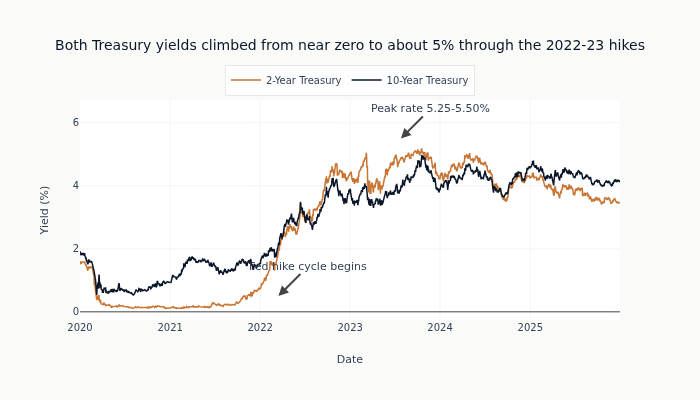


Key insight: When 2Y > 10Y, the yield curve is 'inverted', which has
historically preceded recessions by 6-18 months.


In [8]:
# Build the whole chart in one cell. Splitting the traces and the layout across cells
# auto-displays a title-less, annotation-less intermediate before the finished figure
# (the last trace-adding statement returns the figure and renders it). 2Y in copper vs
# 10Y in blue stay distinguishable where the curve inverts and the lines cross.
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=yields_pd[date_col],
        y=yields_pd["dgs2"],
        mode="lines",
        name="2-Year Treasury",
        line=dict(color=COLORS["copper"], width=1.5),
    )
)
fig.add_trace(
    go.Scatter(
        x=yields_pd[date_col],
        y=yields_pd["dgs10"],
        mode="lines",
        name="10-Year Treasury",
        line=dict(color=COLORS["blue"], width=1.5),
    )
)
for date, label, y_pos in [
    ("2022-03-16", "Fed hike cycle begins", 0.5),
    ("2023-07-26", "Peak rate 5.25-5.50%", 5.5),
]:
    fig.add_annotation(
        x=date, y=y_pos, text=label, showarrow=True, arrowhead=2, arrowsize=1, ax=30, ay=-30
    )
fig.update_layout(
    title="Both Treasury yields climbed from near zero to about 5% through the 2022-23 hikes",
    xaxis_title="Date",
    yaxis_title="Yield (%)",
    height=400,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
)
fig.show()

print("\nKey insight: When 2Y > 10Y, the yield curve is 'inverted', which has")
print("historically preceded recessions by 6-18 months.")

## 4. VIX Volatility Index

The VIX measures implied volatility from S&P 500 options. Spikes indicate
market fear and can be used for regime detection.

In [9]:
# VIX (volatility) - lowercase column names
vix = macro.select([date_col, "vixcls"]).drop_nulls().sort(date_col)
latest_vix = vix.item(-1, "vixcls")
latest_vix_date = vix.item(-1, date_col)

print(f"Observations: {len(vix):,}")
print(f"Latest in dataset ({latest_vix_date}): {latest_vix:.1f}")
print(f"Historical mean: {vix['vixcls'].mean():.1f}")
print(f"Historical max: {vix['vixcls'].max():.1f} (crisis peak)")

Observations: 9,495
Latest in dataset (2025-12-31): 14.9
Historical mean: 19.8
Historical max: 82.7 (crisis peak)


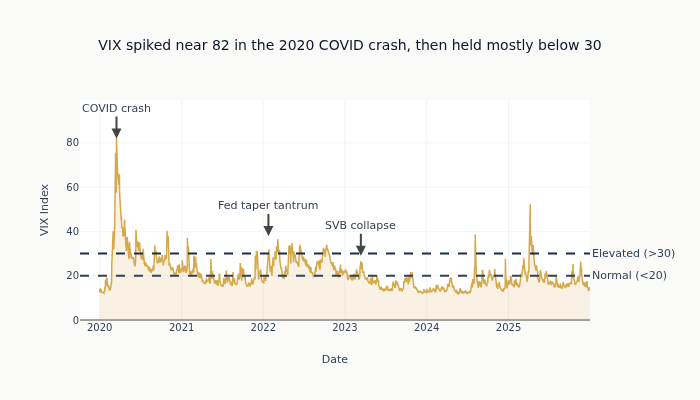


Regime thresholds:
  VIX < 15: Low volatility (risk-on)
  VIX 15-20: Normal
  VIX 20-30: Elevated
  VIX > 30: High volatility (risk-off)


In [10]:
# Whole figure in one cell so only the finished chart renders (the hline calls below
# return the figure and would otherwise auto-display a title-less intermediate). The
# right margin leaves room for the regime-threshold labels so they are not clipped.
vix_recent = vix.filter(pl.col(date_col) >= pl.lit("2020-01-01").str.to_date())
vix_pd = vix_recent.to_pandas()

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=vix_pd[date_col],
        y=vix_pd["vixcls"],
        mode="lines",
        name="VIX",
        line=dict(color=COLORS["amber"], width=1.5),
        fill="tozeroy",
        fillcolor="rgba(212, 168, 75, 0.15)",  # translucent COLORS["amber"]
    )
)
# Regime thresholds
fig.add_hline(
    y=20,
    line_dash="dash",
    line_color=COLORS["neutral"],
    annotation_text="Normal (<20)",
    annotation_position="right",
)
fig.add_hline(
    y=30,
    line_dash="dash",
    line_color=COLORS["slate"],
    annotation_text="Elevated (>30)",
    annotation_position="right",
)
for date, label, y_pos in [
    ("2020-03-16", "COVID crash", 82),
    ("2022-01-24", "Fed taper tantrum", 38),
    ("2023-03-13", "SVB collapse", 29),
]:
    fig.add_annotation(x=date, y=y_pos, text=label, showarrow=True, arrowhead=2, ax=0, ay=-30)
fig.update_layout(
    title="VIX spiked near 82 in the 2020 COVID crash, then held mostly below 30",
    xaxis_title="Date",
    yaxis_title="VIX Index",
    height=400,
    showlegend=False,
    margin=dict(r=110),
)
fig.show()

print("\nRegime thresholds:")
print("  VIX < 15: Low volatility (risk-on)")
print("  VIX 15-20: Normal")
print("  VIX 20-30: Elevated")
print("  VIX > 30: High volatility (risk-off)")

## 5. Yield Curve Spread and Inversions

The 10Y-2Y spread is a key recession indicator. Inversions (spread < 0) have
preceded every US recession since 1970.

In [11]:
slope = macro.select([date_col, "t10y2y"]).drop_nulls()
inversions = slope.filter(pl.col("t10y2y") < 0).height
total_days = slope.height

print("t10y2y = DGS10 - DGS2 (10-Year minus 2-Year Treasury Constant Maturity)")
print(
    f"Yield curve inversions (spread < 0): {inversions:,} days ({100 * inversions / total_days:.1f}%)"
)

t10y2y = DGS10 - DGS2 (10-Year minus 2-Year Treasury Constant Maturity)
Yield curve inversions (spread < 0): 1,467 days (15.5%)


In [12]:
# Yield curve spread visualization
slope_recent = slope.filter(pl.col(date_col) >= pl.lit("2020-01-01").str.to_date())
slope_pd = slope_recent.to_pandas()

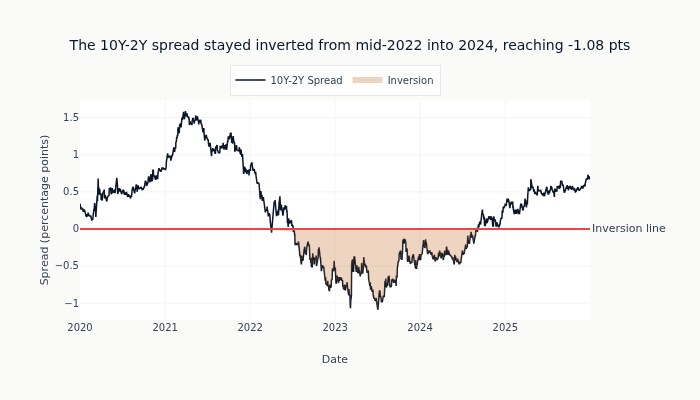

Inversion statistics (since 2020):
  Days inverted: 789 (36.0%)
  Deepest inversion: -1.08%
  Most recent value: 0.71%


In [13]:
# Whole figure in one cell so only the finished chart renders (the hline call returns
# the figure and would otherwise auto-display a title-less intermediate); the right
# margin keeps the inversion-line label on-plot.
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=slope_pd[date_col],
        y=slope_pd["t10y2y"],
        mode="lines",
        name="10Y-2Y Spread",
        line=dict(color=COLORS["blue"], width=1.5),
    )
)
# Shade inversion periods (spread < 0)
inverted = slope_pd[slope_pd["t10y2y"] < 0]
if len(inverted) > 0:
    fig.add_trace(
        go.Scatter(
            x=inverted[date_col],
            y=inverted["t10y2y"],
            mode="none",
            fill="tozeroy",
            fillcolor="rgba(200, 117, 51, 0.3)",  # translucent COLORS["copper"]
            name="Inversion",
            showlegend=True,
        )
    )
fig.add_hline(
    y=0,
    line_dash="solid",
    line_color=COLORS["negative"],
    line_width=2,
    annotation_text="Inversion line",
    annotation_position="right",
)
fig.update_layout(
    title="The 10Y-2Y spread stayed inverted from mid-2022 into 2024, reaching -1.08 pts",
    xaxis_title="Date",
    yaxis_title="Spread (percentage points)",
    height=400,
    margin=dict(r=110),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
)
fig.show()

print("Inversion statistics (since 2020):")
print(f"  Days inverted: {len(inverted)} ({100 * len(inverted) / len(slope_pd):.1f}%)")
print(f"  Deepest inversion: {slope_pd['t10y2y'].min():.2f}%")
print(f"  Most recent value: {slope_pd['t10y2y'].iloc[-1]:.2f}%")

## 6. Mixed Frequency Handling

Economic data releases at different frequencies:
- **Daily**: Treasury yields, VIX
- **Weekly**: Initial claims (ICSA)
- **Monthly**: Unemployment rate (UNRATE), CPI

**Forward-fill** is the correct point-in-time approach (no future leakage).

In [14]:
for series in ["dgs10", "unrate", "icsa"]:
    non_null = macro.filter(pl.col(series).is_not_null())
    freq_info = meta.filter(pl.col(series_col) == series)
    freq = freq_info["native_frequency"][0]
    print(f"  {series.upper():6}  {freq:8}  {len(non_null):,} observations")

  DGS10   daily     9,495 observations
  UNRATE  monthly   9,497 observations
  ICSA    weekly    9,497 observations


In [15]:
macro_filled = macro.with_columns(
    pl.col("unrate").forward_fill().alias("unrate_filled"),
)
(
    macro_filled.select([date_col, "unrate", "unrate_filled"])
    .filter(pl.col(date_col).dt.year() == 2024)
    .head(10)
)

timestamp,unrate,unrate_filled
date,f64,f64
2024-01-01,3.7,3.7
2024-01-02,3.7,3.7
2024-01-03,3.7,3.7
2024-01-04,3.7,3.7
2024-01-05,3.7,3.7
2024-01-06,3.7,3.7
2024-01-07,3.7,3.7
2024-01-08,3.7,3.7
2024-01-09,3.7,3.7


## 7. Multi-Series Dashboard

A combined view of key macro indicators helps identify regime changes.

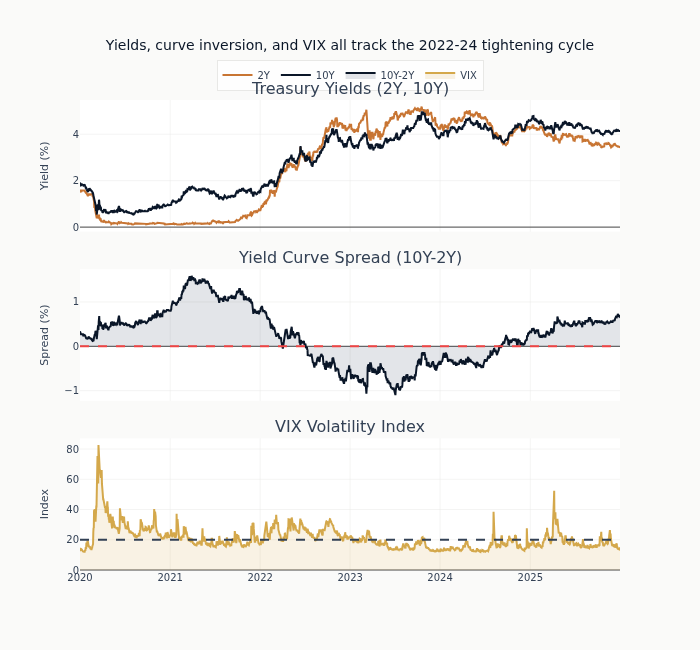


Dashboard interpretation:
  - Rising yields + inverted curve = Tightening cycle, recession risk
  - VIX spikes often coincide with curve moves
  - Use together for regime detection in Chapter 8


In [16]:
# Build the three-panel macro dashboard in a single cell so the inline
# renderer captures the fully populated figure rather than a partial,
# first-panel-only intermediate.
fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    subplot_titles=(
        "Treasury Yields (2Y, 10Y)",
        "Yield Curve Spread (10Y-2Y)",
        "VIX Volatility Index",
    ),
    vertical_spacing=0.08,
)

# Filter to recent data
start_date = "2020-01-01"
recent = macro.filter(pl.col(date_col) >= pl.lit(start_date).str.to_date()).to_pandas()

# Panel 1: Yields
fig.add_trace(
    go.Scatter(
        x=recent[date_col],
        y=recent["dgs2"],
        mode="lines",
        name="2Y",
        line=dict(color=COLORS["copper"]),
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=recent[date_col],
        y=recent["dgs10"],
        mode="lines",
        name="10Y",
        line=dict(color=COLORS["blue"]),
    ),
    row=1,
    col=1,
)

# Panel 2: Spread
fig.add_trace(
    go.Scatter(
        x=recent[date_col],
        y=recent["t10y2y"],
        mode="lines",
        name="10Y-2Y",
        line=dict(color=COLORS["blue"]),
        fill="tozeroy",
        fillcolor="rgba(26, 45, 74, 0.12)",  # translucent COLORS["slate"]
    ),
    row=2,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["negative"], row=2, col=1)

# Panel 3: VIX
fig.add_trace(
    go.Scatter(
        x=recent[date_col],
        y=recent["vixcls"],
        mode="lines",
        name="VIX",
        line=dict(color=COLORS["amber"]),
        fill="tozeroy",
        fillcolor="rgba(212, 168, 75, 0.15)",  # translucent COLORS["amber"]
    ),
    row=3,
    col=1,
)
fig.add_hline(y=20, line_dash="dash", line_color=COLORS["neutral"], row=3, col=1)

fig.update_layout(
    height=650,
    title_text="Yields, curve inversion, and VIX all track the 2022-24 tightening cycle",
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
)

fig.update_yaxes(title_text="Yield (%)", row=1, col=1)
fig.update_yaxes(title_text="Spread (%)", row=2, col=1)
fig.update_yaxes(title_text="Index", row=3, col=1)

fig.show()

print("\nDashboard interpretation:")
print("  - Rising yields + inverted curve = Tightening cycle, recession risk")
print("  - VIX spikes often coincide with curve moves")
print("  - Use together for regime detection in Chapter 8")

## Key Takeaways

1. **Mixed frequencies**: Economic data releases daily, weekly, or monthly
2. **Forward-fill for PIT**: Prevents lookahead bias in feature construction
3. **Pre-computed spreads**: Yield curve slopes ready for regime detection
4. **25 series**: Treasury, credit, volatility, labor market indicators

### Next Steps

- **07_macro_data_alignment**: Multi-frequency integration, point-in-time queries
- **Ch8**: Building macro regime features
- **Ch12**: Macro factor models and regime detection

## Optional: Live FRED Updates

For production workflows with live FRED API updates, the `ml4t-data` library
provides a `MacroDataManager` (Treasury curves, credit spreads, incremental
updates) and a `FREDProvider` for custom series. Both require a free FRED
API key from
[fred.stlouisfed.org](https://fred.stlouisfed.org/docs/api/api_key.html);
the parquet files above are sufficient for the rest of this book.

```python
from ml4t.data.macro import MacroDataManager
from ml4t.data.providers.fred import FREDProvider

mgr = MacroDataManager()
mgr.download_treasury_yields()       # Treasury curve
mgr.download_credit_spreads()        # IG/HY spreads
mgr.update()                         # Incremental refresh

provider = FREDProvider()
provider.fetch_ohlcv("UMCSENT", start="2020-01-01")  # Consumer sentiment
```